# Unified Lab 6: Strategic Interactions & Opponent Modeling

## The Scenario
**You are the Lead AI Architect at "AeroLogistics."** You are no longer just fighting gravity; you are fighting the free market. A rival delivery corporation, "SkyDyne," has deployed its own fleet in the exact same metropolitan airspace.

Every hour, both companies must simultaneously select one of three main flight corridors (Altitude A, Altitude B, or Altitude C) for their heavy drone traffic. Due to complex wind drafts and wake turbulence, this creates a dynamic competitive game (mathematically identical to Rock-Paper-Scissors):
* **Altitude A** gains a speed advantage over **Altitude B**.
* **Altitude B** gains a speed advantage over **Altitude C**.
* **Altitude C** gains a speed advantage over **Altitude A**.
* If both choose the same altitude, it causes air-traffic congestion and both lose time.

You need to build an AI that doesn't just learn a static environment, but actively models and exploits SkyDyne's routing strategy.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/geraldmc/unified-labs/blob/main/the_game_theoretician-6/Module6-Lab.ipynb)

## Milestone 1 (The Baseline): The Historical Frequency Model (Fictitious Play)
**Objective:** Build an Opponent Modeler that tracks the rival's past actions to estimate their underlying probability distribution, forming the foundation of empirical strategy prediction.


### The Architect's Blueprint

Instruct your AI to build an agent class (`OpponentModelingAgent`) focused purely on observation and prediction (we will add the decision-making logic in the next milestone). Give the AI these specific constraints:
* **Action Space:** There are 3 discrete actions (0, 1, 2).
* **The Tracker:** The agent must maintain an internal count of how many times the opponent has played each specific action over the course of the interaction.
* **The Predictor (`get_opponent_probabilities`):** This method must return a probability distribution array by dividing the count of each action by the total number of actions observed. (Make sure the AI handles the edge case of step 0, where no actions have been observed yet, by returning a uniform distribution: `[1/3, 1/3, 1/3]`).
* Instantiate the class as `modeling_agent` so it can be evaluated by the Test Harness.

In [1]:
# ============================================================
# MILESTONE 1: The Historical Frequency Model (Fictitious Play)
# ============================================================
# Every hour SkyDyne picks one of three corridors:
#
#   action  corridor     beats
#   0       Altitude A   Altitude B (1)
#   1       Altitude B   Altitude C (2)
#   2       Altitude C   Altitude A (0)
#
# Fictitious Play assumes the rival is drawing from a FIXED distribution, so the
# best estimate of that distribution is simply the empirical frequency of each
# action seen so far. Every observation, no matter how old, counts equally.

import numpy as np

N_ACTIONS = 3


class OpponentModelingAgent:
    """Tracks the opponent's action counts and predicts their empirical distribution."""

    def __init__(self, n_actions=N_ACTIONS):
        self.n_actions = n_actions
        self.opponent_counts = np.zeros(n_actions, dtype=int)

    def update_opponent_history(self, action):
        """Record one observed opponent action (an integer in [0, n_actions))."""
        if not 0 <= action < self.n_actions:
            raise ValueError(f"action must be in [0, {self.n_actions}), got {action}")
        self.opponent_counts[action] += 1

    def get_opponent_probabilities(self):
        """Return count / total for each action, or a uniform prior before any observation."""
        total = self.opponent_counts.sum()
        if total == 0:
            # Step 0: nothing observed yet, so no action is more likely than another.
            return np.full(self.n_actions, 1.0 / self.n_actions)
        return self.opponent_counts / total


modeling_agent = OpponentModelingAgent()
print("Prior before any observation:", modeling_agent.get_opponent_probabilities())

Prior before any observation: [0.33333333 0.33333333 0.33333333]


### The Test Harness

*Use this exact block of code; your AI's generated code MUST pass these assertions.*

In [2]:
# MILESTONE 1 TEST HARNESS - DO NOT MODIFY

import numpy as np

# Test 1: Ensure the agent has the correct tracking methods
assert hasattr(modeling_agent, 'update_opponent_history'), "Agent must have a method to record opponent actions."
assert hasattr(modeling_agent, 'get_opponent_probabilities'), "Agent must have a method to return predicted probabilities."

# Test 2: Simulate observing the opponent
# Opponent plays: A(0), A(0), B(1), A(0)
modeling_agent.update_opponent_history(0)
modeling_agent.update_opponent_history(0)
modeling_agent.update_opponent_history(1)
modeling_agent.update_opponent_history(0)

# Test 3: Verify the predicted probability distribution
probs = modeling_agent.get_opponent_probabilities()
assert len(probs) == 3, "Probabilities must cover all 3 possible altitudes."
assert round(sum(probs), 5) == 1.0, "Probabilities must sum to 1.0."
assert probs[0] == 0.75, "Agent should predict a 75% chance of the opponent choosing Altitude A based on history."
assert probs[1] == 0.25, "Agent should predict a 25% chance of the opponent choosing Altitude B."
assert probs[2] == 0.0, "Agent should predict a 0% chance of the opponent choosing Altitude C."

### Architect's Audit (Milestone 1)

1. Look at the underlying logic of your `get_opponent_probabilities` method. It treats all historical observations with equal weight. Imagine the rival drone's AI is programmed to play Action 0 for the first 1,000 rounds, but then suddenly switches to playing Action 1 exclusively. Mathematically, what is the flaw in relying on an unweighted historical average, and how long (in rounds) will it take for your agent to even predict a $50\%$ chance that the opponent plays Action 1?

Question One:

An unweighted average assumes the rival's strategy never changes and weights every round equally. After $n$ observations, each new round shifts the estimate by only $1/(n+1)$ of the gap between the old belief and new evidence, making the model increasingly stubborn. After 1,000 rounds of Action 0, it treats a switch to Action 1 as more evidence from the same distribution, letting stale observations outweigh the new behavior.

After $k$ rounds of Action 1, $P(1) = \frac{k}{1000 + k}$. Setting $P(1)=0.5$ gives $k=1000$: the agent needs 1,000 rounds—matching its exposure to the old behavior—to reach 50%, exceeding it only on round 1,001. Until then, its best response remains Action 0. Although Action 2 beats Action 0, Action 1 beats Action 2, so SkyDyne wins until the counts are even. Thus, adaptation costs rise with the duration of the old behavior—the opposite of what is desirable against a rival that can change strategy at any time.


## Milestone 2 (The Best Response): Exploiting the Model
**Objective:** Use the probability distribution generated by your Opponent Modeler to calculate the expected value of every possible action, and systematically choose the action that maximizes your payoff.

### The Architect's Blueprint

Instruct your AI to build a `BestResponseAgent` class (it can inherit from your Milestone 1 agent or be a new class). Give the AI these specific constraints:
* **The Payoff Matrix:** Define the environment's rules mathematically as a 2D array/list. Rows represent your agent's action; Columns represent the opponent's action.
    * Win = `+1`, Lose = `-1`, Tie (Congestion) = `-1`.
    * Remember: Action 0 beats 1; Action 1 beats 2; Action 2 beats 0.
* **The Math (`get_expected_values`):** Create a method that takes the opponent's probability distribution as input. It must multiply the payoffs for each of your actions by the probability of the opponent playing the corresponding response, summing them up to find the Expected Value (EV) of playing Action 0, 1, and 2.
* **The Policy (`get_best_response`):** Create a method that evaluates the expected values and returns the integer of the action with the highest EV (e.g., using `np.argmax`).
* Instantiate the class as `best_response_agent` so it can be evaluated by the Test Harness.

In [3]:
# ============================================================
# MILESTONE 2: The Best Response (exploiting the model)
# ============================================================
# Payoff matrix from OUR point of view: rows = our action, columns = SkyDyne's.
#
#              SkyDyne:  A(0)  B(1)  C(2)
#   us  A(0)             -1    +1    -1      A beats B
#       B(1)             -1    -1    +1      B beats C
#       C(2)             +1    -1    -1      C beats A
#
# The diagonal is -1, not 0: picking the same corridor causes congestion and
# BOTH fleets lose time. So this is RPS-shaped but not zero-sum.
#
# Given a predicted opponent distribution p, the expected value of each of our
# actions is one matrix-vector product:  EV = PAYOFF_MATRIX @ p

PAYOFF_MATRIX = np.array([
    [-1, +1, -1],
    [-1, -1, +1],
    [+1, -1, -1],
])


class BestResponseAgent(OpponentModelingAgent):
    """Fictitious Play: model the opponent by frequency, then play the action with the highest EV."""

    def __init__(self, n_actions=N_ACTIONS, payoff_matrix=PAYOFF_MATRIX):
        super().__init__(n_actions)
        self.payoff_matrix = np.asarray(payoff_matrix, dtype=float)

    def get_expected_values(self, opponent_probs):
        """EV[i] = sum over j of payoff[i, j] * P(opponent plays j)."""
        return self.payoff_matrix @ np.asarray(opponent_probs, dtype=float)

    def get_best_response(self, opponent_probs=None):
        """Return the action with the highest EV (defaults to the agent's own opponent model).

        np.argmax returns the FIRST maximal index, so ties always resolve to the
        lowest-numbered action (see the audit below).
        """
        if opponent_probs is None:
            opponent_probs = self.get_opponent_probabilities()
        return int(np.argmax(self.get_expected_values(opponent_probs)))


best_response_agent = BestResponseAgent()

# Audit probe: a (near-)uniform opponent makes every action equally good.
uniform = [0.333, 0.333, 0.333]
print("EVs vs uniform opponent:", best_response_agent.get_expected_values(uniform))
print("Best response chosen:   ", best_response_agent.get_best_response(uniform))

# Audit probe: our agent is a deterministic function of public history, so a
# rival that runs a copy of it can predict our move and play its counter.
COUNTER = {0: 2, 1: 0, 2: 1}       # the action that beats each of ours
victim = BestResponseAgent()
our_moves, payoffs = [], []
for _ in range(300):
    ours = victim.get_best_response()
    theirs = COUNTER[ours]
    our_moves.append(ours)
    payoffs.append(PAYOFF_MATRIX[ours, theirs])
    victim.update_opponent_history(theirs)
print("Our first 12 moves vs a mind-reading rival:", our_moves[:12])
print(f"Rounds lost: {payoffs.count(-1)} / {len(payoffs)}, total payoff {sum(payoffs)}")

EVs vs uniform opponent: [-0.333 -0.333 -0.333]
Best response chosen:    0
Our first 12 moves vs a mind-reading rival: [0, 1, 1, 2, 2, 0, 0, 1, 1, 2, 2, 0]
Rounds lost: 300 / 300, total payoff -300


### The Test Harness

*Use this exact block of code; your AI's generated code MUST pass these assertions.*


In [4]:
# MILESTONE 2 TEST HARNESS - DO NOT MODIFY

# Test 1: Verify the expected value calculation
# Assume opponent has an 80% chance to play 0, 20% to play 1, 0% to play 2.
dummy_probs = [0.8, 0.2, 0.0]
expected_values = best_response_agent.get_expected_values(dummy_probs)

assert len(expected_values) == 3, "Must calculate an expected value for all 3 actions."
# Action 2 beats Action 0 (+1). 80% of the time we get +1, 20% we get -1 (Action 2 loses to Action 1). EV = 0.6
assert round(expected_values[2], 5) == 0.6, "Expected value for Action 2 is mathematically incorrect."

# Test 2: Verify the best response selection
best_action = best_response_agent.get_best_response(dummy_probs)
assert best_action == 2, "Agent failed to select the mathematically optimal action."

### Architect's Audit (Milestone 2)

1. Pass a perfectly uniform distribution (`[0.333, 0.333, 0.333]`) into your `get_expected_values` function. Look at the resulting expected values. Because they are mathematically identical, how does your policy function (like `np.argmax`) break the tie? If your agent defaults to a hardcoded tie-breaker (e.g., always picking Action 0 when EVs are equal), explain mechanically how "SkyDyne" (the rival AI) could easily exploit your agent, even though your agent thinks it is playing "optimally" against a random opponent.

Question One:

With uniform input `[0.333, 0.333, 0.333]`, each expected value is $-0.333$ (or $-1/3$ for a true uniform distribution): each action beats one corridor and loses or congests against the other two, yielding $0.333 \times (+1 - 1 - 1)$. `np.argmax` breaks the tie by choosing the **first** maximal index, so the agent always plays Action 0 (Altitude A). Against a truly random opponent, any action is a best response, since each is worth $-1/3$.

The weakness is predictability. With no prior observations, the agent opens with Altitude A, while SkyDyne chooses C, which beats it. Because our agent deterministically bases its moves on SkyDyne's past moves, SkyDyne can copy our code, predict each move, and counter it. The probe does this, defeating our agent in **all 300 rounds**. Our agent also follows a fixed cycle (0, 1, 1, 2, 2, 0, …), while a countering rival keeps its history nearly balanced, forcing predictable ties or near-ties.

The agent is "optimal" only if SkyDyne draws from a fixed distribution and ignores our actions—an assumption a strategic rival violates. To avoid predictability, randomize ties or use a mixed strategy when indifferent; then SkyDyne cannot predict and counter our move.


## Milestone 3 (The Upgrade): Adaptive Opponent Modeling

**Objective:** Overcome the inertia of standard Fictitious Play by implementing an Exponentially Weighted Moving Average (EWMA). This allows your agent to "forget" the distant past and rapidly adapt to sudden shifts in the rival's strategy.


### The Architect's Blueprint

Instruct your AI to build an `AdaptiveModelingAgent` class that predicts the opponent's moves, but discards the simple "counting" method from Milestone 1. Give the AI these specific constraints:
* **The Tracker:** Instead of counting total historical actions, the agent directly maintains its predicted probability distribution `opponent_probs` (initialized to `[1/3, 1/3, 1/3]`).
* **The Math:** Implement an update rule using a decay factor (learning rate) $\alpha$. When the opponent plays an action, update the distribution: $P_{new} = (1 - \alpha) \times P_{old} + \alpha \times \text{Observed Action (as a one-hot array)}$.
* **Hyperparameter:** Set $\alpha = 0.2$.
* Instantiate the class as `adaptive_agent` so it can be evaluated by the Test Harness.
* **The Simulation:** Write a loop that simulates 100 rounds. For the first 50 rounds, the opponent plays Action 0 exclusively. For the next 50 rounds, the opponent plays Action 1 exclusively. Feed this identical data to *both* your Milestone 1 agent and your new Milestone 3 agent. Plot their predicted probability of Action 1 over time on the same graph.

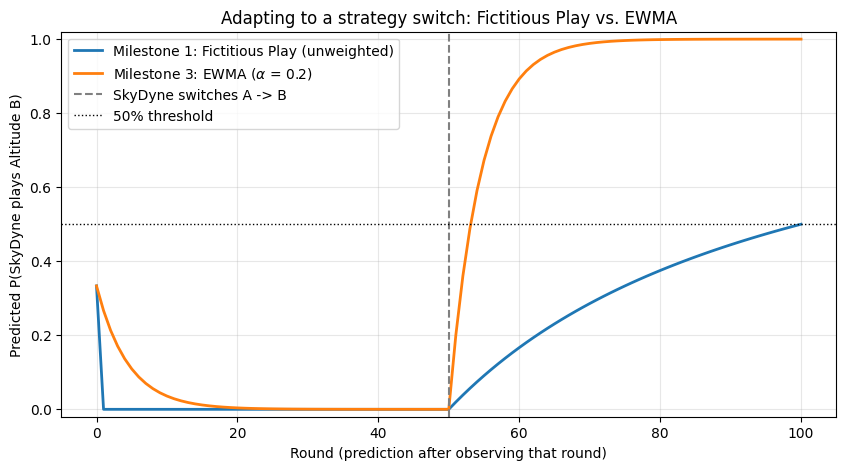

Fictitious Play  P(B) at round 100: 0.5000; first > 50%: never within 100 rounds
EWMA             P(B) at round 100: 1.0000; first > 50%: round 54 (4 rounds after the switch)

Weight of round 1's observation in the prediction after round 60:
  Fictitious Play: 1/60 = 0.0167
  EWMA:            alpha * (1 - alpha)^59 = 3.83e-07


In [5]:
# ============================================================
# MILESTONE 3: Adaptive Opponent Modeling (EWMA)
# ============================================================
# Fictitious Play gives every past round equal weight, so its estimate moves by
# only 1/(n+1) per observation and grows more stubborn the longer it watches.
# An exponentially weighted moving average keeps the belief itself and nudges it
# toward each new observation by a FIXED step alpha:
#
#   P_new = (1 - alpha) * P_old + alpha * one_hot(observed action)
#
# Unrolled, the observation from k rounds ago carries weight alpha * (1 - alpha)^k,
# so old evidence fades geometrically instead of piling up. Since both terms sum
# to 1 and one_hot sums to 1, P_new stays a valid distribution automatically.

import matplotlib.pyplot as plt

ALPHA = 0.2


class AdaptiveModelingAgent:
    """Predicts the opponent with an exponentially weighted moving average of their actions."""

    def __init__(self, n_actions=N_ACTIONS, alpha=ALPHA):
        self.n_actions = n_actions
        self.alpha = alpha                                        # decay factor / learning rate
        self.opponent_probs = np.full(n_actions, 1.0 / n_actions)  # uniform prior

    def update_opponent_history(self, action):
        """Move the predicted distribution a fraction alpha toward the observed action."""
        if not 0 <= action < self.n_actions:
            raise ValueError(f"action must be in [0, {self.n_actions}), got {action}")
        one_hot = np.zeros(self.n_actions)
        one_hot[action] = 1.0
        self.opponent_probs = (1 - self.alpha) * np.asarray(self.opponent_probs) + self.alpha * one_hot

    def get_opponent_probabilities(self):
        """Return a copy of the current predicted distribution."""
        return np.array(self.opponent_probs, dtype=float)


adaptive_agent = AdaptiveModelingAgent()

# --- Simulation: SkyDyne plays A(0) for 50 rounds, then switches to B(1) for 50 ---
# Fresh instances: the Milestone 1 harness already fed modeling_agent four observations.
N_ROUNDS, SWITCH_ROUND = 100, 50
opponent_actions = [0] * SWITCH_ROUND + [1] * (N_ROUNDS - SWITCH_ROUND)

fp_agent = OpponentModelingAgent()
ewma_agent = AdaptiveModelingAgent()
fp_p1 = [fp_agent.get_opponent_probabilities()[1]]       # index 0 = prior, before round 1
ewma_p1 = [ewma_agent.get_opponent_probabilities()[1]]
for action in opponent_actions:
    fp_agent.update_opponent_history(action)
    ewma_agent.update_opponent_history(action)
    fp_p1.append(fp_agent.get_opponent_probabilities()[1])
    ewma_p1.append(ewma_agent.get_opponent_probabilities()[1])

rounds = np.arange(N_ROUNDS + 1)
plt.figure(figsize=(10, 5))
plt.plot(rounds, fp_p1, label="Milestone 1: Fictitious Play (unweighted)", linewidth=2)
plt.plot(rounds, ewma_p1, label=f"Milestone 3: EWMA ($\\alpha$ = {ALPHA})", linewidth=2)
plt.axvline(SWITCH_ROUND, color="gray", linestyle="--", label="SkyDyne switches A -> B")
plt.axhline(0.5, color="black", linestyle=":", linewidth=1, label="50% threshold")
plt.xlabel("Round (prediction after observing that round)")
plt.ylabel("Predicted P(SkyDyne plays Altitude B)")
plt.title("Adapting to a strategy switch: Fictitious Play vs. EWMA")
plt.ylim(-0.02, 1.02)
plt.legend(loc="upper left")
plt.grid(alpha=0.3)
plt.show()

# --- Audit numbers (deterministic: no randomness anywhere in this simulation) ---
def first_round_above_half(p1):
    hits = [t for t in rounds if t > SWITCH_ROUND and p1[t] > 0.5]
    return hits[0] if hits else None

for name, p1 in [("Fictitious Play", fp_p1), ("EWMA", ewma_p1)]:
    t = first_round_above_half(p1)
    when = f"round {t} ({t - SWITCH_ROUND} rounds after the switch)" if t else f"never within {N_ROUNDS} rounds"
    print(f"{name:16s} P(B) at round {N_ROUNDS}: {p1[-1]:.4f}; first > 50%: {when}")

t = 60
print(f"\nWeight of round 1's observation in the prediction after round {t}:")
print(f"  Fictitious Play: 1/{t} = {1 / t:.4f}")
print(f"  EWMA:            alpha * (1 - alpha)^{t - 1} = {ALPHA * (1 - ALPHA) ** (t - 1):.2e}")

### The Test Harness

*Use this exact block of code; your AI's generated code MUST pass these assertions.*


In [6]:
# MILESTONE 3 TEST HARNESS - DO NOT MODIFY

# Test 1: Verify initialization and update structure
assert hasattr(adaptive_agent, 'alpha'), "Agent must have a learning rate/decay factor (alpha)."
assert hasattr(adaptive_agent, 'opponent_probs'), "Agent must maintain an internal probability distribution."

# Test 2: Simulate the exact scenario from the Milestone 1 Audit
# Opponent plays Action 0 for a long time, then suddenly switches to Action 1.
# Let's start the agent with an artificial history where it heavily believes the opponent plays Action 0.
adaptive_agent.opponent_probs = np.array([0.99, 0.01, 0.0])

# Observe Action 1 just TWO times.
adaptive_agent.update_opponent_history(1)
adaptive_agent.update_opponent_history(1)

# Test 3: Verify rapid adaptation (Assuming an alpha of 0.2)
probs = adaptive_agent.get_opponent_probabilities()
assert round(sum(probs), 5) == 1.0, "Probabilities must still sum to 1.0."
assert probs[1] > 0.35, "Agent should have adapted much faster than the unweighted model."

### Architect's Audit (Milestone 3)

1. Examine the plot comparing the two agents. Look specifically at round 50, where the opponent suddenly switches to Action 1. How many rounds does it take for the Milestone 1 agent to predict a $>50\%$ chance of Action 1? How many rounds does it take for the Milestone 3 agent? Mathematically, what happens to the "weight" of the opponent's round 1 behavior by the time your adaptive agent reaches round 60?

Question One:

After the switch at round 50, the Milestone 1 agent **never exceeds 50% in the 100-round simulation**. After $k$ rounds of Altitude B, its prediction is $rac{k}{50 + k}$: exactly $0.5$ at round 100 ($k = 50$), first exceeding it at round 101, beyond the plot. It needs as many rounds of the new behavior as it saw of the old. The Milestone 3 agent exceeds 50\% at **round 54, four rounds after the switch**. Its belief in B is then essentially zero, so after $k$ B observations it predicts $P(B) \\approx 1 - 0.8^k$. This is $0.488$ after three rounds and $0.590$ after four; $0.8^k < 0.5$ first holds at $k = 4$.

Unrolling the update rule explains why: an observation from $k$ rounds ago has weight $alpha(1-alpha)^k$. After round 60, round 1’s weight is $0.2$ times $0.8^{59}$ approx 3.8 times $10^{-7}$—effectively zero. Fictitious Play still gives it $1/60$ approx $0.017$, retaining a $1/n$ share forever. The 50 Altitude A rounds together contribute just $0.8^{10}-0.8^{60}$ approx $0.107$ to the adaptive agent at round 60, versus $50/60$ approx $0.83$ for Fictitious Play. Thus, EWMA effectively remembers only the last $1/alpha=5$ rounds, letting it track a rival that changes strategy, unlike Fictitious Play.


## The Summary Audit

To complete the lab, submit your generated notebook along with brief, 3-4 sentence answers to the following questions:

1. **Data-Binding (The Memory Tradeoff):** You set your $\alpha$ value to $0.2$, which allowed the agent to adapt quickly. What would happen to your agent's predictive stability if you set $\alpha = 0.99$? Refer specifically to the mathematical update rule ($P_{new} = (1 - \alpha) \times P_{old} + \dots$) to explain why a very high $\alpha$ might make your agent too reactive to a single random mistake made by the opponent.
2. **The AI Consultation & Application:** Ask your preferred AI assistant: *"In Game Theory, what is the Nash Equilibrium strategy for a standard game of Rock-Paper-Scissors?"* Read the AI's explanation. Then, mathematically trace what happens if SkyDyne (the opponent) perfectly executes this Nash Equilibrium strategy against your `BestResponseAgent` from Milestone 2. If SkyDyne's true distribution is perfectly uniform, what specific Expected Value will your agent calculate for all three of its actions, and why does this mean your agent can no longer gain an exploitative advantage?

**1. Data-Binding (The Memory Tradeoff):**

With $\alpha = 0.99$, $P_{new} = 0.01 \times P_{old} + 0.99 \times \text{one-hot}$, so the latest move supplies 99% of the belief and all prior observations just 1%. A move from $k$ rounds ago retains weight $0.99 \times 0.01^k$, effectively limiting memory to one round and prompting the agent to predict, “SkyDyne will repeat its last move." If SkyDyne plays Altitude A 95% of the time but detours to B once, the belief jumps to about 99% B. The agent switches from C (which beats A) to A (which beats B); when SkyDyne returns to A, both fleets congest at $-1$. Small $\alpha$ smooths noise; large $\alpha$ reacts to every blip. Thus, $\alpha = 0.2$ retains about five rounds of memory, filtering one-off errors while tracking genuine strategy changes within a few rounds.

**2. The AI Consultation & Application:**

The AI explains that Rock-Paper-Scissors’ Nash equilibrium is to choose each option independently and randomly with probability $1/3$. Against this uniform play, our agent calculates $EV = 0.333 \times (+1) + 0.333 \times (-1) + 0.333 \times (-1) = -1/3$ for every action, rather than the standard RPS value of $0$, because congestion ties also cost $-1$. Uniform play remains an equilibrium: all actions yield $-1/3$, so no pure or mixed strategy performs better. Always breaking ties by choosing Altitude A is harmless because a truly random SkyDyne does not model us. We can only accept the game’s congestion cost of $-1/3$ per round.